In [21]:
# pip install nba_api
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import playercareerstats, shotchartdetail
from nba_api.stats.static import players
import time
import plotly.express as px


In [2]:
player_list = ['Stephen Curry', 'Shai Gilgeous-Alexander', 'Giannis Antetokounmpo', 'LeBron James', 'Rudy Gobert',\
'Shaquille O\'Neal', 'DeAndre Jordan', 'Jeremy Lin', 'Anthony Edwards', 'Kobe Bryant']

In [3]:
# box = pd.read_csv('data/boxscore.csv')
# game = pd.read_csv('data/games.csv')[['seasonStartYear', 'pointsAway', 'game_id']]

In [4]:
# df = box[box['playerName'].isin(player_list)]
# df = df.merge(game, on = 'game_id')
# df = df[df['MP'] != 'Did Not Play']
# df['+/-'] = df['+/-'].str.strip('+').apply(pd.to_numeric, errors='coerce')
# df['seasonStartYear'] = df['seasonStartYear'].astype(str)
# df[['FG', 'FGA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']] = df[['FG', 'FGA', '3P', '3PA', 'FT', 'FTA', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS']].apply(pd.to_numeric, errors='coerce')


In [5]:
# totals = df.groupby(['playerName', 'seasonStartYear'])[['FT', 'FTA']].sum().reset_index()
# totals['FT%'] = totals['FT'] / totals['FTA']
# totals.sort_values('FT%', ascending=False)
# for player, color in [('Stephen Curry', 'green'), ('DeAndre Jordan', 'red')]:
#     fig = totals[totals['playerName'] == player].plot(kind = 'line', x = 'seasonStartYear', y = 'FT%', title = f'{player} FT%', color = color)
#     fig.set_ylim(.3, 1)

In [6]:
# df.plot(kind = 'scatter', x = 'FT', y = '+/-', title = 'Effect of FT Made on Player Impact')
# df.plot(kind = 'scatter', x = 'FTA', y = '+/-', title = 'Effect of FT Attempts on Player Impact')

In [7]:
# totals = df.groupby('playerName')[['PTS', 'FT']].sum().reset_index()
# totals['proportion'] = (round((totals['FT'] / totals['PTS']) * 100, 2))#.apply(str) + '%'
# totals

# # Assuming 'totals' is a DataFrame already defined
# ax = (
#     totals.sort_values('PTS', ascending=False)
#     .plot(
#         kind='bar',
#         x='playerName',
#         y=['FT', 'PTS'],
#         stacked=True,
#         figsize=(12, 6),  # Adjust figure size
#         title='Free Throw Points vs Total Points'  # Clearer Title
#     )
# )

# # Customizing the Legend
# ax.legend(['Free Throw Points', 'Total Points'])

# # Customizing Labels and Rotation
# ax.set_xlabel('Player Name')
# ax.set_ylabel('Points')
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Displaying the Plot
# plt.tight_layout()
# plt.show()


In [8]:
pids = list()
for pid in player_list:
    pids.append(players.find_players_by_full_name(pid)[0]['id'])

In [9]:
# Example: Stephen Curry in the 2023-24 season
response = shotchartdetail.ShotChartDetail(
    team_id=0,                       # 0 = all teams
    player_id=201939,               # Stephen Curry's ID
    season_type_all_star='Regular Season',
    season_nullable='2023-24',
    context_measure_simple='FGA',  # Field Goal Attempts
)

# Convert to DataFrame
df = response.get_data_frames()[0]
# print(df[['LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'SHOT_MADE_FLAG']].head())


In [10]:
df['POINTS'] = df.apply(lambda x: 3*x['SHOT_MADE_FLAG'] if x['SHOT_TYPE'][0] == '3' else 2*x['SHOT_MADE_FLAG'], axis = 1)

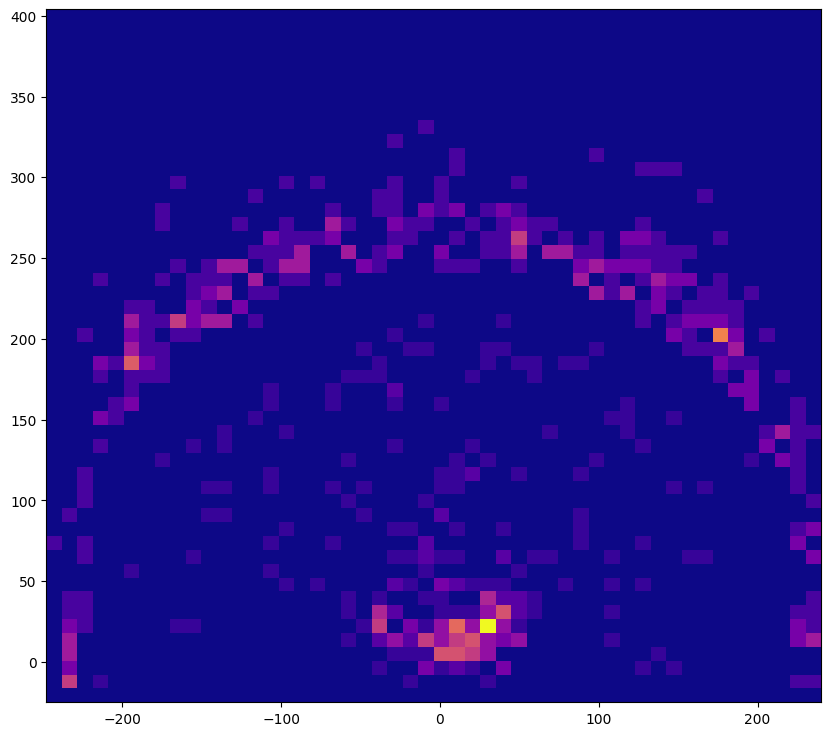

In [11]:
# shots = df.drop(df['LOC_Y'].idxmax()).sample(1000)
shots = df[df['LOC_Y'] < 450]
x = shots['LOC_X']
y = shots['LOC_Y']

x_bins = 50
y_bins = 50

# Create 2D histogram
plt.figure(figsize=(10, 9))
plt.hist2d(x, y, weights = shots['POINTS'], bins=[x_bins, y_bins], cmap='plasma')
# plt.gca().set_aspect('equal')
plt.show()

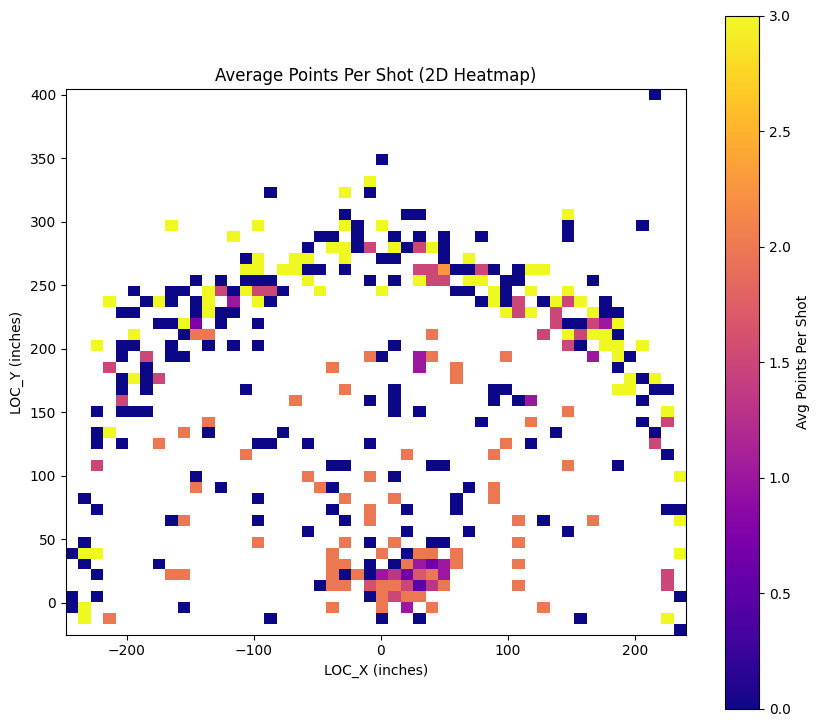

In [12]:
shots = df[df['LOC_Y'] < 450].sample(500)
plt.figure(figsize=(10, 9))
hb = plt.hist2d(
    x=shots['LOC_X'],
    y=shots['LOC_Y'],
    bins=[50, 50],  # grid resolution
    weights=shots['POINTS'],  # sum of points in each bin
    cmap='viridis',
    cmin=0
)

# Divide sum of points by number of shots per bin to get avg points per shot
counts, _, _ = np.histogram2d(shots['LOC_X'], shots['LOC_Y'], bins=hb[1:3])
average_points = hb[0] / np.where(counts == 0, np.nan, counts)  # avoid div by 0

# Plot average points per shot as heatmap
plt.clf()  # clear the previous plot
plt.imshow(
    np.flipud(average_points.T),
    extent=[hb[1][0], hb[1][-1], hb[2][0], hb[2][-1]],
    cmap='plasma',
    interpolation='nearest',
    aspect='equal'
)
plt.colorbar(label='Avg Points Per Shot')
plt.title("Average Points Per Shot (2D Heatmap)")
plt.xlabel("LOC_X (inches)")
plt.ylabel("LOC_Y (inches)")
plt.gca().set_aspect('equal')
plt.show()

In [13]:
# creating all_players_shots.csv

# df = pd.DataFrame()

# for pid in pids:
#     try:
#         career = playercareerstats.PlayerCareerStats(player_id=pid, timeout=60)
#         player_szns = career.get_data_frames()[0]['SEASON_ID'].unique()
#     except Exception as e:
#         print(f"❌ Failed to fetch seasons for player {pid}: {e}")
#         continue

#     for szn in player_szns:
#         try:
#             # season_str = szn.replace("20", "", 1)  # Convert '2023-24' -> '23-24'
#             print(f"📊 Player {pid}, Season {szn}")
#             response = shotchartdetail.ShotChartDetail(
#                 team_id=0,
#                 player_id=pid,
#                 season_type_all_star='Regular Season',
#                 season_nullable=szn,
#                 context_measure_simple='FGA',
#                 timeout=60
#             )
#             df = pd.concat([df, response.get_data_frames()[0]], ignore_index=True)
#             time.sleep(1)  # avoid rate-limiting
#         except Exception as e:
#             print(f"⚠️ Failed for player {pid}, season {szn}: {e}")
#             continue
# df['POINTS'] = df.apply(lambda x: 3*x['SHOT_MADE_FLAG'] if x['SHOT_TYPE'][0] == '3' else 2*x['SHOT_MADE_FLAG'], axis = 1)

# df.to_csv('all_players_shots.csv', index = False)

In [14]:
df = pd.read_csv('../data/all_players_shots.csv')

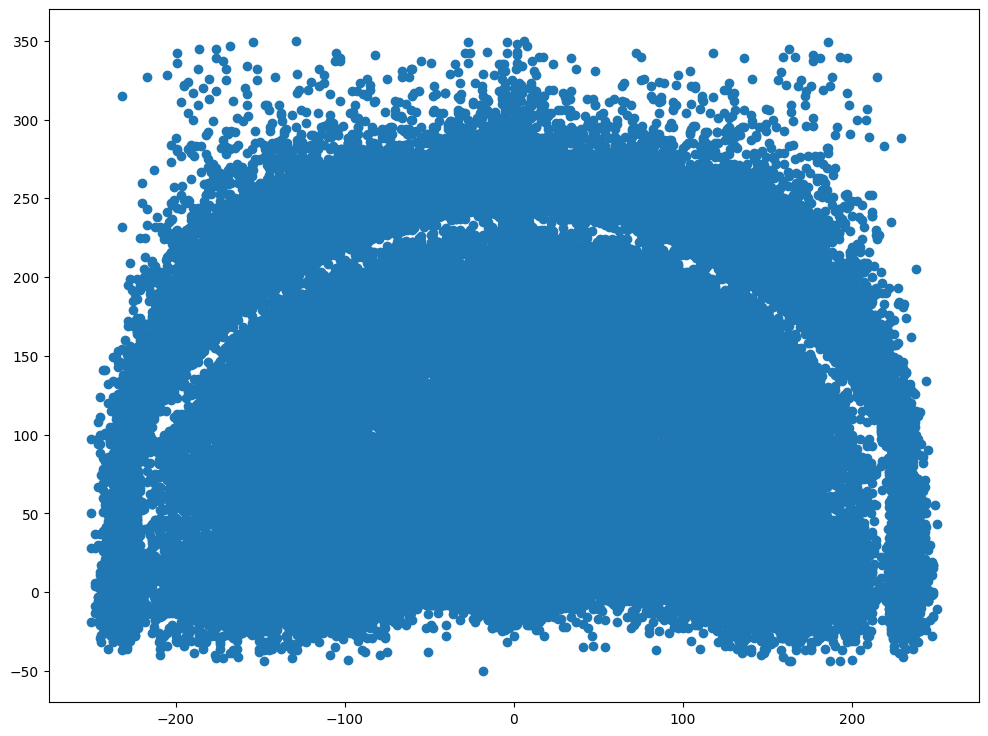

In [15]:
shots = df[df['LOC_Y'] <= 350]
plt.figure(figsize=(12,9))
plt.scatter(shots['LOC_X'], shots['LOC_Y'])
plt.show()

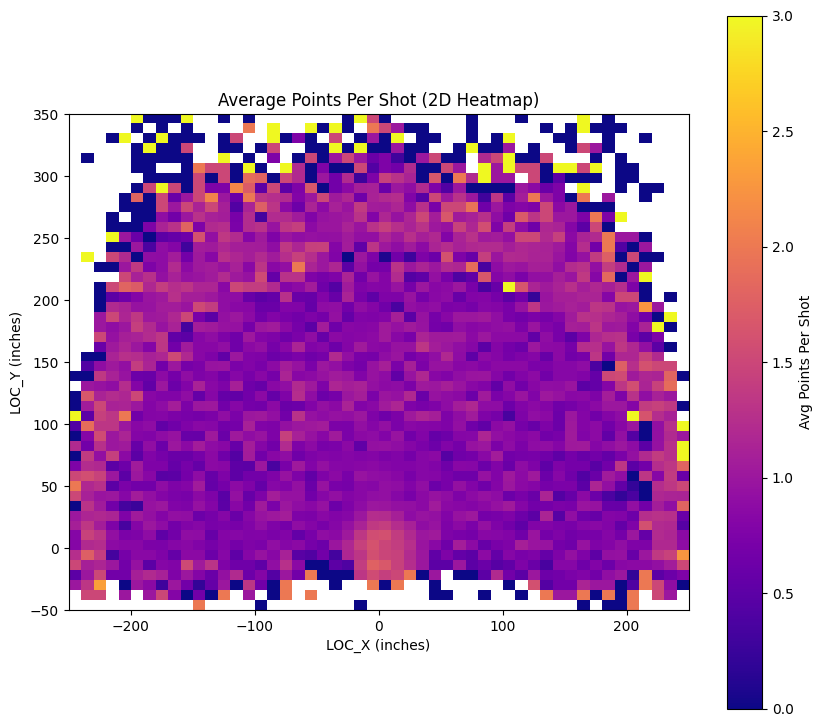

In [16]:
plt.figure(figsize=(10, 9))
hb = plt.hist2d(
    x=shots['LOC_X'],
    y=shots['LOC_Y'],
    bins=[50, 50],  # grid resolution
    weights=shots['POINTS'],  # sum of points in each bin
    cmap='viridis',
    cmin=0
)

# Divide sum of points by number of shots per bin to get avg points per shot
counts, _, _ = np.histogram2d(shots['LOC_X'], shots['LOC_Y'], bins=hb[1:3])
average_points = hb[0] / np.where(counts == 0, np.nan, counts)  # avoid div by 0

# Plot average points per shot as heatmap
plt.clf()  # clear the previous plot
plt.imshow(
    np.flipud(average_points.T),
    extent=[hb[1][0], hb[1][-1], hb[2][0], hb[2][-1]],
    cmap='plasma',
    interpolation='nearest',
    aspect='equal'
)
plt.colorbar(label='Avg Points Per Shot')
plt.title("Average Points Per Shot (2D Heatmap)")
plt.xlabel("LOC_X (inches)")
plt.ylabel("LOC_Y (inches)")
plt.gca().set_aspect('equal')
plt.show()

In [17]:
df

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,POINTS
0,Shot Chart Detail,20900015,4,201939,Stephen Curry,1610612744,Golden State Warriors,1,11,25,...,24+ ft.,26,99,249,1,0,20091028,GSW,HOU,0
1,Shot Chart Detail,20900015,17,201939,Stephen Curry,1610612744,Golden State Warriors,1,9,31,...,16-24 ft.,18,-122,145,1,1,20091028,GSW,HOU,2
2,Shot Chart Detail,20900015,53,201939,Stephen Curry,1610612744,Golden State Warriors,1,6,2,...,8-16 ft.,14,-60,129,1,0,20091028,GSW,HOU,0
3,Shot Chart Detail,20900015,141,201939,Stephen Curry,1610612744,Golden State Warriors,2,9,49,...,16-24 ft.,19,-172,82,1,0,20091028,GSW,HOU,0
4,Shot Chart Detail,20900015,249,201939,Stephen Curry,1610612744,Golden State Warriors,2,2,19,...,16-24 ft.,16,-68,148,1,0,20091028,GSW,HOU,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133790,Shot Chart Detail,21501228,462,977,Kobe Bryant,1610612747,Los Angeles Lakers,4,3,5,...,Less Than 8 ft.,0,6,-6,1,1,20160413,LAL,UTA,2
133791,Shot Chart Detail,21501228,475,977,Kobe Bryant,1610612747,Los Angeles Lakers,4,1,45,...,Less Than 8 ft.,0,-7,2,1,1,20160413,LAL,UTA,2
133792,Shot Chart Detail,21501228,479,977,Kobe Bryant,1610612747,Los Angeles Lakers,4,1,27,...,8-16 ft.,14,69,129,1,1,20160413,LAL,UTA,2
133793,Shot Chart Detail,21501228,482,977,Kobe Bryant,1610612747,Los Angeles Lakers,4,0,59,...,24+ ft.,25,-232,110,1,1,20160413,LAL,UTA,3


In [18]:
total_shots = df.groupby('PLAYER_NAME')['SHOT_ATTEMPTED_FLAG'].sum()

In [25]:
shots_per_zone = df.groupby(['PLAYER_NAME', 'SHOT_ZONE_BASIC'])[['SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG']].sum().reset_index()
shots_per_zone['SHOOTING%'] = shots_per_zone['SHOT_MADE_FLAG'] / shots_per_zone['SHOT_ATTEMPTED_FLAG']
shots_per_zone = shots_per_zone.set_index('PLAYER_NAME')
shots_per_zone['ATTEMPT%'] = shots_per_zone['SHOT_ATTEMPTED_FLAG'] / total_shots
shots_per_zone = shots_per_zone.sort_values(['PLAYER_NAME', 'ATTEMPT%', 'SHOOTING%'], ascending=False)
shots_per_zone = shots_per_zone.rename(columns = {'SHOT_ATTEMPTED_FLAG': 'ATTEMPTS', 'SHOT_MADE_FLAG': 'MAKES'}).reset_index()
shots_per_zone

,PLAYER_NAME,SHOT_ZONE_BASIC,ATTEMPTS,MAKES,SHOOTING%,ATTEMPT%
0,Stephen Curry,Above the Break 3,8235,3448,0.418701,0.448700
1,Stephen Curry,Mid-Range,3563,1643,0.461128,0.194137
2,Stephen Curry,Restricted Area,3273,2067,0.631531,0.178336
3,Stephen Curry,In The Paint (Non-RA),1935,881,0.455297,0.105432
4,Stephen Curry,Left Corner 3,715,339,0.474126,0.038958
...,...,...,...,...,...,...
60,Anthony Edwards,In The Paint (Non-RA),1023,393,0.384164,0.142738
61,Anthony Edwards,Mid-Range,967,338,0.349535,0.134924
62,Anthony Edwards,Left Corner 3,212,80,0.377358,0.029580
63,Anthony Edwards,Right Corner 3,141,51,0.361702,0.019674


In [33]:
zones = shots_per_zone['SHOT_ZONE_BASIC'].unique()
for zone in zones:
    zone_df = shots_per_zone[shots_per_zone['SHOT_ZONE_BASIC'] == zone]
    # plt.scatter(zone_df['ATTEMPT%'], zone_df['SHOOTING%'])
    fig = px.scatter(
        zone_df,
        x = 'ATTEMPT%',
        y = 'SHOOTING%',
        hover_name = 'PLAYER_NAME',
        title = f'Zone: {zone}'
    )
    # plt.show()
    fig.show()